# 08 - AQI Category Classification and Model Evaluation
**Project:** Air Quality & Pollution Intelligence - Data Mining and Business Intelligence

**Objective:** Predict the AQI band from pollutant concentrations with several algorithms, avoid data leakage, respect the class imbalance, and compare the models on a held-out split.

**How to read this notebook:** every number printed below is produced by the
code in this notebook from `data/raw/Air_quality_data.csv`. Column names are
discovered at runtime through `src/config.py`, so nothing is assumed.


In [1]:
"""Environment bootstrap: make src/ importable and pin the working directory."""
import sys, os, warnings
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)
%matplotlib inline
print("project root:", PROJECT_ROOT)

project root: C:\Users\DELL\OneDrive\Desktop\Air Quality


In [2]:
import config as C
import data_utils as U
import preprocessing as P
import feature_engineering as FE
import classification as CL
import figures as F
import viz as V
from IPython.display import display, Image

clean, *_ = P.clean(U.load_raw())
feat, _ = FE.build_features(clean)
polls = C.pollutant_columns(feat.columns)
target = C.TARGET_COL
model_df = CL.drop_non_informative(feat, target)
print("records with a usable AQI band:", f"{len(model_df):,}")

records with a usable AQI band: 18,265


## 1. Target and class balance

Accuracy is meaningless without the class distribution, so the balance is measured
first and a prior-based baseline is carried through every comparison.

In [3]:
balance = CL.class_balance(model_df, target)
display(balance)
print(f"imbalance ratio (largest/smallest class): {balance.attrs['imbalance_ratio']}")
print(f"majority class: {balance.attrs['majority_class']} "
      f"({balance.attrs['majority_share_pct']}%) -> baseline accuracy")

,Class,Count,Percent,Rank
0,Very Poor,5501,30.12,1
1,Severe,5258,28.79,2
2,Moderate,4258,23.31,3
3,Poor,3129,17.13,4
4,Satisfactory,113,0.62,5
5,Good,6,0.03,6


imbalance ratio (largest/smallest class): 916.8
majority class: Very Poor (30.12%) -> baseline accuracy


## 2. Data leakage: the AQI column must not be a predictor

`AQI_Bucket` is a banding of `AQI` (proved in notebook 02), so giving a model the
AQI number to predict the AQI band is predicting the target from itself. The cell
below measures how much that mistake would inflate the score.

In [4]:
leak = CL.leakage_check(model_df, polls, target)
display(pd.DataFrame([leak]).T.rename(columns={0: "value"})
        if False else pd.Series(
            {"accuracy without AQI (%)": leak["without leaky column"]["accuracy_%"],
             "accuracy with AQI (%)": leak["with leaky column"]["accuracy_%"],
             "inflation (pp)": leak["accuracy_inflation_pp"],
             "macro F1 without AQI": leak["without leaky column"]["macro_F1"],
             "macro F1 with AQI": leak["with leaky column"]["macro_F1"]}).to_frame("value"))
print()
print(leak["verdict"])
(C.PROCESSED_DIR / "leakage_check.json").write_text(__import__("json").dumps(leak, indent=2),
                                                    encoding="utf-8")

,value
accuracy without AQI (%),99.2800
accuracy with AQI (%),99.9600
inflation (pp),0.6800
macro F1 without AQI,0.7355
macro F1 with AQI,0.8276



including AQI inflates accuracy by 0.68 percentage points, so AQI is excluded from all reported models


434

## 3. Models and their settings

| Model | Why included | Key settings |
|---|---|---|
| Baseline (prior) | reference point that any real model must beat | always predicts the largest class |
| Logistic Regression | linear, interpretable multi-class reference | L2, one-vs-rest internals, `class_weight="balanced"`, features scaled |
| Decision Tree | single transparent model, non-linear | `max_depth=12`, `min_samples_leaf=20`, balanced weights |
| Random Forest | bagged ensemble, robust, gives feature importances | 200 trees, `min_samples_leaf=2`, `balanced_subsample` |
| Hist Gradient Boosting | modern boosted benchmark | 250 iterations, learning rate 0.1 |

All use `random_state=42`, a stratified 75/25 split, and 3-fold stratified CV for
the accuracy column.

In [5]:
comp, reports, matrices, split_info, pred_frame, y_test, X_test = CL.train_and_evaluate(
    model_df, polls, target, cv_folds=3)
display(comp)
print()
print("features given to the models:", split_info["features_used"])
print("excluded as leaky          :", split_info["excluded_leaky_column"])
print("train / test rows          :", split_info["train_rows"], "/", split_info["test_rows"])

,Model,Accuracy_%,Precision_macro,Recall_macro,F1_macro,Precision_weighted,F1_weighted,Lift_over_Baseline_pp,CV_Folds,CV_Accuracy_%,CV_Std_pp
0,Random Forest,99.28,0.8181,0.7532,0.7765,0.9922,0.9921,69.17,3,99.17,0.17
1,Decision Tree,94.94,0.6921,0.7829,0.7153,0.9569,0.9522,64.83,3,94.78,0.38
2,Hist Gradient Boosting,89.69,0.6206,0.6352,0.6224,0.9059,0.9009,59.58,3,90.51,4.27
3,Logistic Regression,31.55,0.2485,0.5077,0.2491,0.3553,0.3247,1.44,3,31.95,0.64
4,Baseline (prior),30.11,0.0502,0.1667,0.0771,0.0906,0.1393,0.00,3,30.12,0.01



features given to the models: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']
excluded as leaky          : AQI
train / test rows          : 13698 / 4567


In [6]:
comp.to_csv(C.MODEL_COMPARISON_CSV, index=False)
display(comp[["Model", "Accuracy_%", "Precision_macro", "Recall_macro", "F1_macro",
             "Lift_over_Baseline_pp", "CV_Accuracy_%"]])

,Model,Accuracy_%,Precision_macro,Recall_macro,F1_macro,Lift_over_Baseline_pp,CV_Accuracy_%
0,Random Forest,99.28,0.8181,0.7532,0.7765,69.17,99.17
1,Decision Tree,94.94,0.6921,0.7829,0.7153,64.83,94.78
2,Hist Gradient Boosting,89.69,0.6206,0.6352,0.6224,59.58,90.51
3,Logistic Regression,31.55,0.2485,0.5077,0.2491,1.44,31.95
4,Baseline (prior),30.11,0.0502,0.1667,0.0771,0.00,30.12


## 4. Why macro-F1 and per-class recall, not just accuracy

The four main bands hold over 99% of records; `Good` holds 6 rows and
`Satisfactory` 113. A model can therefore look excellent overall while never
detecting the rare classes.

In [7]:
per_class = pd.concat([CL.report_to_frame(n, r) for n, r in reports.items()],
                     ignore_index=True)
rare = per_class[per_class["Class"].isin(["Good", "Satisfactory"])]
display(rare)
print("Support is the number of test records in that class; recall is the share found.")

,Model,Class,Precision,Recall,F1-Score,Support
0,Baseline (prior),Good,0.0000,0.0000,0.0000,2
3,Baseline (prior),Satisfactory,0.0000,0.0000,0.0000,28
8,Logistic Regression,Good,0.0500,1.0000,0.0952,2
11,Logistic Regression,Satisfactory,0.0464,0.7500,0.0873,28
16,Decision Tree,Good,0.0000,0.0000,0.0000,2
19,Decision Tree,Satisfactory,0.3247,0.8929,0.4762,28
24,Random Forest,Good,0.0000,0.0000,0.0000,2
27,Random Forest,Satisfactory,0.9375,0.5357,0.6818,28
32,Hist Gradient Boosting,Good,0.0000,0.0000,0.0000,2
35,Hist Gradient Boosting,Satisfactory,0.0779,0.2143,0.1143,28


Support is the number of test records in that class; recall is the share found.


In [8]:
best = comp.iloc[0]["Model"]
display(pd.DataFrame(reports[best]).T.round(3))

,precision,recall,f1-score,support
Good,0.000,0.000,0.000,2.000
Moderate,0.987,0.990,0.988,1065.000
Poor,0.994,0.997,0.996,782.000
Satisfactory,0.938,0.536,0.682,28.000
Severe,0.995,1.000,0.997,1315.000
Very Poor,0.996,0.996,0.996,1375.000
accuracy,0.993,0.993,0.993,0.993
macro avg,0.818,0.753,0.776,4567.000
weighted avg,0.992,0.993,0.992,4567.000


## 5. Confusion matrices

C:\Users\DELL\OneDrive\Desktop\Air Quality\src\figures.py:424: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


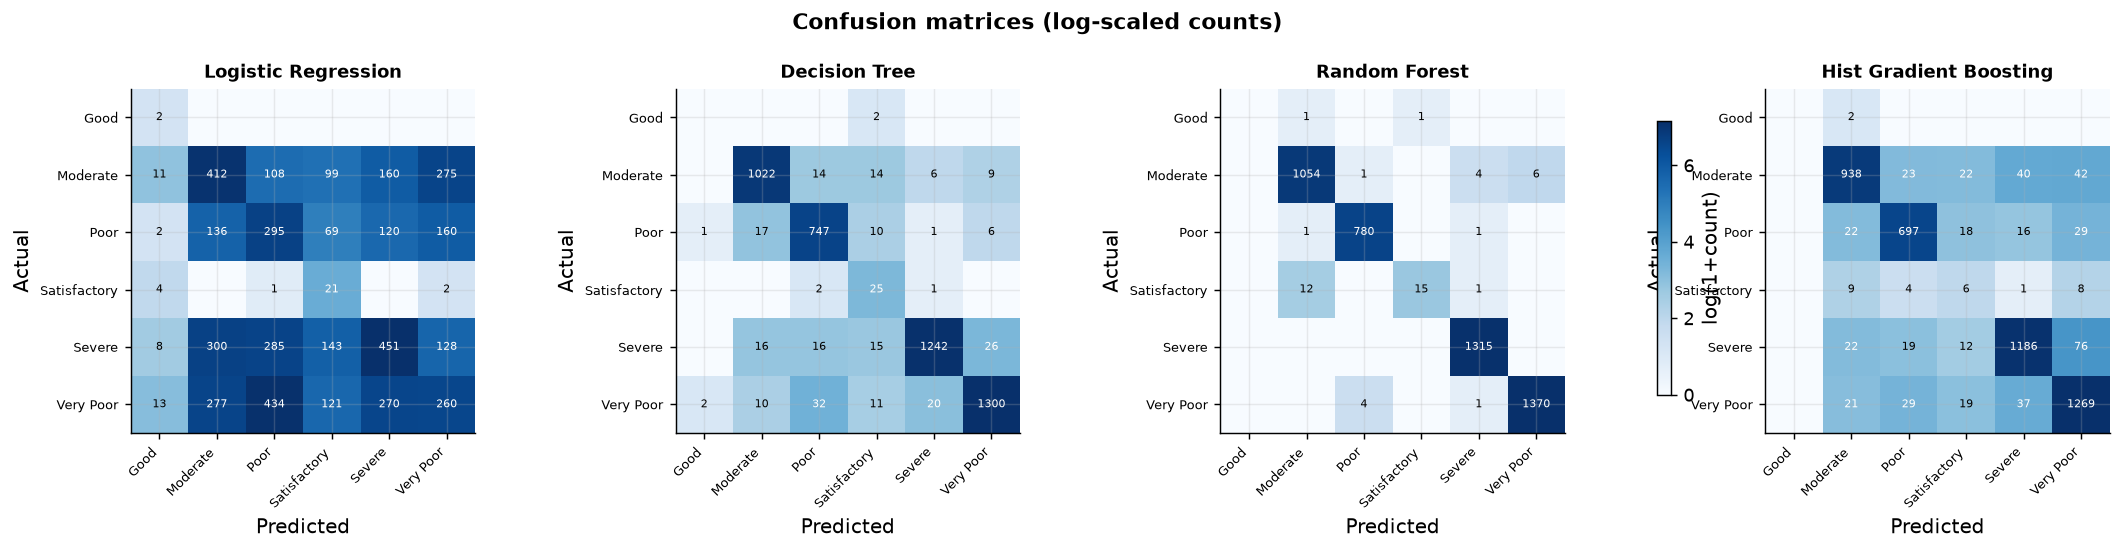

In [9]:
conf = pd.concat([CL.confusion_to_frame(m, sorted(split_info["classes"]), n)
                  for n, m in matrices.items()], ignore_index=True)
conf.to_csv(C.PROCESSED_DIR / "confusion_matrices.csv", index=False)
per_class.to_csv(C.PROCESSED_DIR / "classification_per_class.csv", index=False)
Image(F.classification(comp, conf, per_class, pd.DataFrame(),
                       sorted(split_info["classes"]))["02_confusion_matrices"])

C:\Users\DELL\OneDrive\Desktop\Air Quality\src\figures.py:424: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


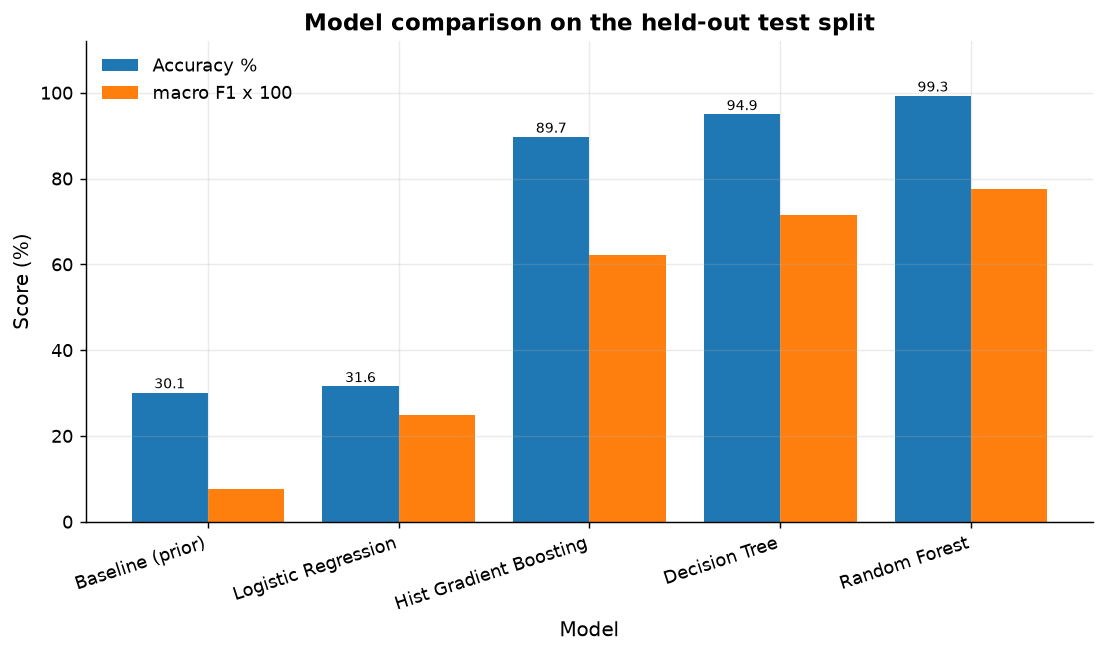

In [10]:
imp_model, imp_features = CL.fit_reference_model(model_df, polls, target)
imp = CL.feature_importance(imp_model, imp_features)
paths = F.classification(comp, conf, per_class, imp,
                         sorted(split_info["classes"]))
Image(paths["01_model_comparison"])

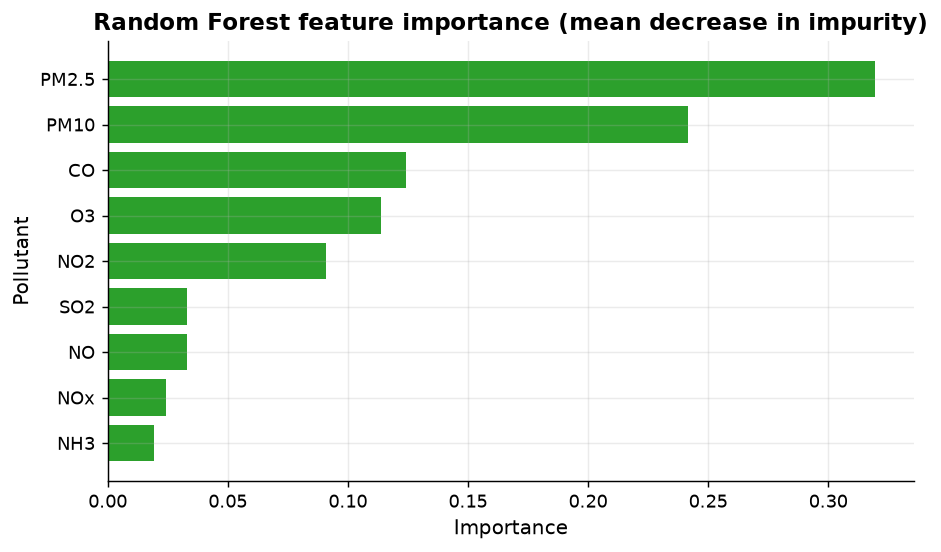

In [11]:
Image(paths["03_per_class_recall"])
Image(paths["04_feature_importance"])

## 6. Which pollutants carry the signal?

Mean-decrease-in-impurity importance from a random forest trained on the full
frame. This is a *model-internal* measure: it says which columns the trees split
on, not which pollutants cause poor air quality.

In [12]:
display(imp)
imp.to_csv(C.PROCESSED_DIR / "feature_importance.csv", index=False)

,Feature,Importance
0,PM2.5,0.31960
1,PM10,0.24174
2,CO,0.12418
3,O3,0.11380
4,NO2,0.09082
5,SO2,0.03313
6,NO,0.03311
7,NOx,0.02446
8,NH3,0.01916


## 7. Test-set predictions exported for the dashboard

Actual-versus-predicted records allow the BI layer to show model reliability
without retraining anything in Power BI.

In [13]:
pred_frame.to_csv(C.CLASSIFICATION_CSV, index=False)
print("saved:", C.CLASSIFICATION_CSV.name, "rows:", f"{len(pred_frame):,}")
display(pred_frame.head(8))

saved: classification_results.csv rows: 4,567


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Actual,Pred_Baseline (prior),Pred_Logistic Regression,Pred_Decision Tree,Pred_Random Forest,Pred_Hist Gradient Boosting
11379,44.7,214.5,129.9,62.5,80.0,34.3,2.02,65.1,166.6,Moderate,Very Poor,Poor,Moderate,Moderate,Moderate
2537,195.5,240.5,81.1,77.5,96.4,34.3,1.90,25.2,96.6,Very Poor,Very Poor,Very Poor,Very Poor,Very Poor,Very Poor
669,354.6,582.1,72.1,120.8,238.4,47.3,2.28,76.2,185.0,Poor,Very Poor,Severe,Poor,Poor,Poor
12919,140.4,557.5,97.0,95.5,128.4,11.0,6.29,48.2,139.6,Very Poor,Very Poor,Severe,Very Poor,Very Poor,Very Poor
13530,141.1,352.4,106.6,29.3,227.1,43.3,0.51,38.9,103.4,Very Poor,Very Poor,Satisfactory,Very Poor,Very Poor,Very Poor
1526,474.1,482.7,15.1,86.1,158.4,10.9,7.88,44.0,107.0,Severe,Very Poor,Severe,Severe,Severe,Severe
7500,481.2,443.8,158.5,149.9,218.3,8.7,6.40,11.7,169.7,Severe,Very Poor,Severe,Severe,Severe,Severe
4750,376.4,2.7,190.7,102.5,42.7,30.2,7.82,15.4,68.8,Moderate,Very Poor,Moderate,Moderate,Moderate,Severe


## Verification checklist

- [x] Leak-proof feature set (AQI excluded, and the inflation measured)
- [x] Stratified split, fixed random state
- [x] Baseline model reported next to every real model
- [x] Class imbalance quantified before accuracy is interpreted
- [x] Precision, recall and F1 reported per class and macro-averaged
- [x] Confusion matrices and feature importances saved

**Common errors**

| Error | Meaning | Fix |
|---|---|---|
| `ConvergenceWarning` in logistic regression | unscaled inputs or too few iterations | features are piped through `StandardScaler` and `max_iter=2000` |
| `UndefinedMetricWarning` | a class has no predicted samples | `zero_division=0` is set; recall is reported instead |
| Accuracy of ~100% | leakage | re-check `leakage_check` above |

**Next:** `09_final_analysis.ipynb`.